# import thư viện

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

# lấy dữ liệu

In [ ]:
data_dir = "/content/Email_cleaned.csv"

In [ ]:
df = pd.read_csv(data_dir)
df

,label,Message
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get medircations online qnb ikud viagra...
2,0,computer connection cnn com wednesday escapenu...
3,1,university degree obtain prosperous future mon...
4,0,thanks answer guy know checked rsync manual wo...
...,...,...
83412,0,hi given date get last date month data form yy...
83413,1,order software cd download site immediately de...
83414,1,dear valued member canadianpharmacy provides w...
83415,0,subscribe change profile contact u long term e...


In [ ]:
from sklearn.model_selection import train_test_split
df_5k, _ = train_test_split(
    df,
    train_size=5000,
    random_state=42,
    stratify=df["label"]
)
df_5k = df_5k.reset_index(drop=True)
print(df_5k["label"].value_counts())

label
1    2631
0    2369
Name: count, dtype: int64


# logistic regression

In [ ]:
def sigmoid(s):
    return 1/(1 + np.exp(-s))

def logistic_regression(X, y, w_init, eta, tol = 1e-4, max_count = 100):
    w = [w_init]
    #it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    while count < max_count:
        # mix data
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            # stopping criteria
            if count%check_w_after == 0:
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w

def predict(w,x_test):
  y_pred = sigmoid(np.dot(w.T,x_test))
  y_label = (y_pred >= 0.5).astype(int)
  return y_label.flatten()

# run

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

np.random.seed(2)
X = df_5k["Message"].astype(str)
y = df_5k["label"].astype(int)

#chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# vector X_train và X_test
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=3,stop_words='english',)
X_train = vectorizer.fit_transform(X_train).toarray()
X_test  = vectorizer.transform(X_test).toarray()

# (n_samples, n_features + 1)
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test  = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

# chuyển về (d,N)
X_train = X_train.T
X_test  = X_test.T

# chuyển về numpy
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [ ]:
eta = 0.1
d = X_train.shape[0]
w_init = np.random.randn(d, 1)

w = logistic_regression(X_train, y_train, w_init, eta)
y_pred = predict(w[-1],X_test)
report = classification_report(y_test, y_pred)
print(report)

# lưu
with open("y_pred_lr.pkl", "wb") as f:
    pickle.dump(y_pred, f)

              precision    recall  f1-score   support

           0       0.83      0.72      0.77       474
           1       0.77      0.87      0.82       526

    accuracy                           0.80      1000
   macro avg       0.80      0.79      0.79      1000
weighted avg       0.80      0.80      0.79      1000



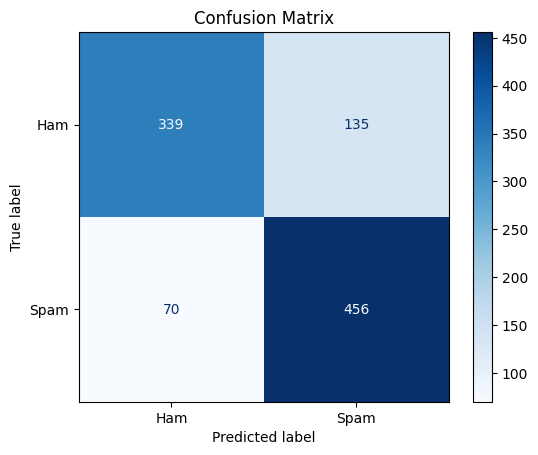

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()